In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torchvision import models, datasets, transforms
from torch.utils.data import Dataset, DataLoader
import cv2, numpy as np, pandas as pd, matplotlib.pyplot as plt
from glob import glob
!pip install torchsummary
from torchsummary import summary

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [3]:
# setup kaggle api
!pip install -q kaggle
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!ls ~/.kaggle
!chmod 600 /root/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
kaggle.json


In [4]:
# download dataset from kaggle
!kaggle datasets download -d tongpython/cat-and-dog

Dataset URL: https://www.kaggle.com/datasets/tongpython/cat-and-dog
License(s): CC0-1.0
 57% 124M/218M [00:00<00:00, 1.29GB/s]
100% 218M/218M [00:00<00:00, 657MB/s] 


In [ ]:
# unzip data
!unzip /content/cat-and-dog.zip

In [6]:
# data folders
train_data_path = '/content/training_set/training_set'
test_data_path = '/content/test_set/test_set'

In [7]:
# dataset
class DogAndCatData(Dataset):
  def __init__(self, folder):
    cats = glob(folder + '/cats/*.jpg')
    dogs = glob(folder + '/dogs/*.jpg')
    self.file_paths = cats[:1000] + dogs[:1000]
    self.normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    from random import shuffle, seed; seed(10)
    shuffle(self.file_paths)
    self.targets = [path.split('/')[-1].startswith('dog') for path in self.file_paths]

  def __len__(self):
    return len(self.file_paths)

  def __getitem__(self, ix):
    f = self.file_paths[ix]
    target = self.targets[ix]
    target = torch.tensor([target])
    img = (cv2.imread(f)[:, :, ::-1]) #bgr to rgb
    img = cv2.resize(img, (224, 224))
    img = torch.tensor(img/225)
    img = img.permute(2, 0, 1)
    img = self.normalize(img)
    return (
        img.float().to(device),
        target.float().to(device)
    )

data = DogAndCatData(train_data_path)

tensor([0.], device='cuda:0')


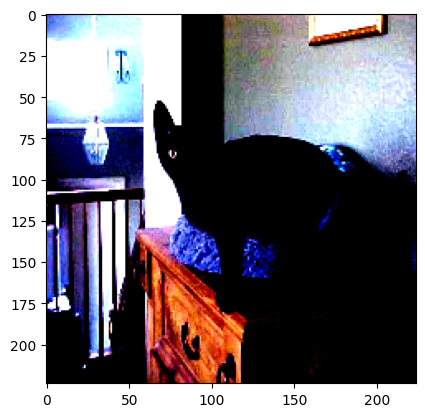

In [8]:
image, label = data[45]
plt.imshow(image.permute(1,2,0).cpu())
print(label)

In [9]:
def get_data():
  train_data = DogAndCatData(train_data_path)
  val_data = DogAndCatData(test_data_path)
  train_dl = DataLoader(train_data, batch_size=32, shuffle=True, drop_last=True)
  val_dl = DataLoader(val_data, batch_size=32, shuffle=True, drop_last=True)
  return train_dl, val_dl

train_dl, val_dl = get_data()

In [10]:
model = models.resnet18(pretrained=True).to(device)
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 205MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
def model():
  model = models.resnet18(pretrained=True)
  for param in model.parameters():
    param.requires_grad = False

  model.avgpool = nn.AdaptiveAvgPool2d(output_size=(1, 1))
  model.fc = nn.Sequential(
      nn.Flatten(),
      nn.Linear(512, 128),
      nn.ReLU(),
      nn.Dropout(0.2),
      nn.Linear(128, 1),
      nn.Sigmoid()
  )
  loss_func = nn.BCELoss()
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
  return model.to(device), loss_func, optimizer

model, loss_func, optimizer = model()

In [12]:
def train(x, y, model, optimizer, loss_func):
  model.train()
  prediction = model(x)
  batch_loss = loss_func(prediction, y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()

In [13]:
@torch.no_grad()
def accuracy(x, y, model):
  model.eval()
  prediction = model(x)
  is_correct = (prediction > 0.5) == y
  return is_correct.cpu().numpy().tolist()

In [14]:
# train model
train_losses, train_accuracies = [], []
val_accuracies = []
for epoch in range(5):
  print('epoch: ', epoch+1)
  train_epoch_losses, train_epoch_accuracies = [], []
  val_epoch_accuracies = []
  # train loss
  for ix, batch in enumerate(iter(train_dl)):
    x, y = batch
    batch_loss = train(x, y, model, optimizer , loss_func)
    train_epoch_losses.append(batch_loss)
  train_epoch_loss = np.array(train_epoch_losses).mean()
  # train accuracy
  for ix, batch in enumerate(iter(train_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    train_epoch_accuracies.extend(is_correct)
  train_epoch_accuracy = np.array(train_epoch_accuracies).mean()
  # val accuracy
  for ix, batch in enumerate(iter(val_dl)):
    x, y = batch
    val_is_correct = accuracy(x, y, model)
    val_epoch_accuracies.extend(val_is_correct)
  val_epoch_accuracy = np.array(val_epoch_accuracies).mean()

  # append losses and accuracies
  train_losses.append(train_epoch_loss)
  train_accuracies.append(train_epoch_accuracy)
  val_accuracies.append(val_epoch_accuracy)

epoch:  1
epoch:  2
epoch:  3
epoch:  4
epoch:  5


In [15]:
print('train accuracy: ', np.array(train_accuracies).mean())
print('train loss: ', np.array(train_losses).mean())
print('val accuracy: ', np.array(val_accuracies).mean())

train accuracy:  0.9678427419354838
train loss:  0.12618679609299907
val accuracy:  0.964616935483871


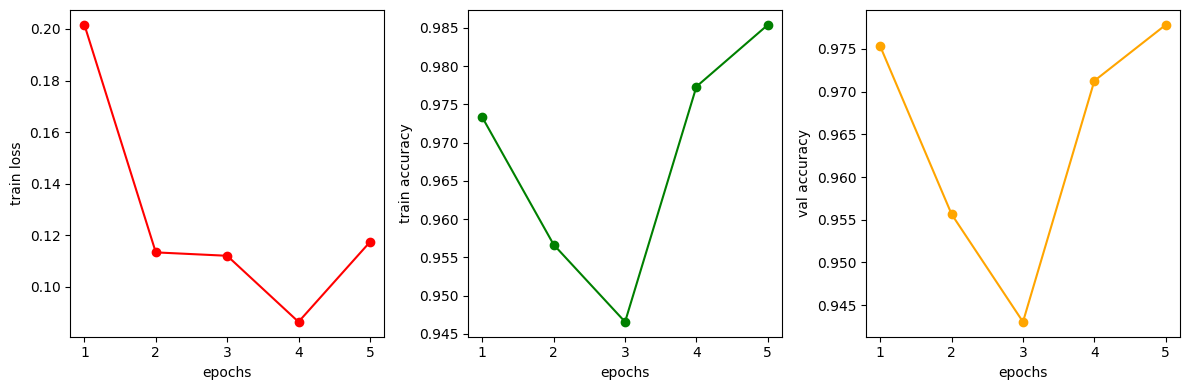

In [17]:
epochs = np.arange(5) + 1
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].plot(epochs, train_losses, color='red', marker='o', label='train loss')
axes[0].set_ylabel('train loss')
axes[0].set_xlabel('epochs')

axes[1].plot(epochs, train_accuracies, color='green', marker='o', label='train accuracy')
axes[1].set_ylabel('train accuracy')
axes[1].set_xlabel('epochs')

axes[2].plot(epochs, val_accuracies, color='orange', marker='o', label='val accuracy')
axes[2].set_ylabel('val accuracy')
axes[2].set_xlabel('epochs')

plt.tight_layout()
plt.show()